Histogram (commits by hour)

Goal:
- Compare **when** students commit during the day on:
  - working days (Mon–Fri)
  - weekends (Sat–Sun)

We will:
1) Load commit timestamps from `checker` (users only).
2) Extract the **hour** of each commit.
3) Plot two histograms on the same axes (working vs weekend).
4) Answer: Are there hours where weekend commits > working-day commits? Show top 4 hours.

In [9]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1) Connect to the SQLite database
con = sqlite3.connect("../data/checking-logs.sqlite")

# 2) Load commit timestamps for users only
q = """
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%';
"""
df = pd.read_sql(q, con, parse_dates=["timestamp"])

# 3) Extract hour + weekday/weekend flag
df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.weekday  # Mon=0 ... Sun=6
df["is_weekend"] = df["weekday"] >= 5

# 4) Build the two lists for histogram input (hours repeated per commit)
hours_working = df[~df["is_weekend"]]["hour"].tolist()
hours_weekend = df[df["is_weekend"]]["hour"].tolist()

con.close()

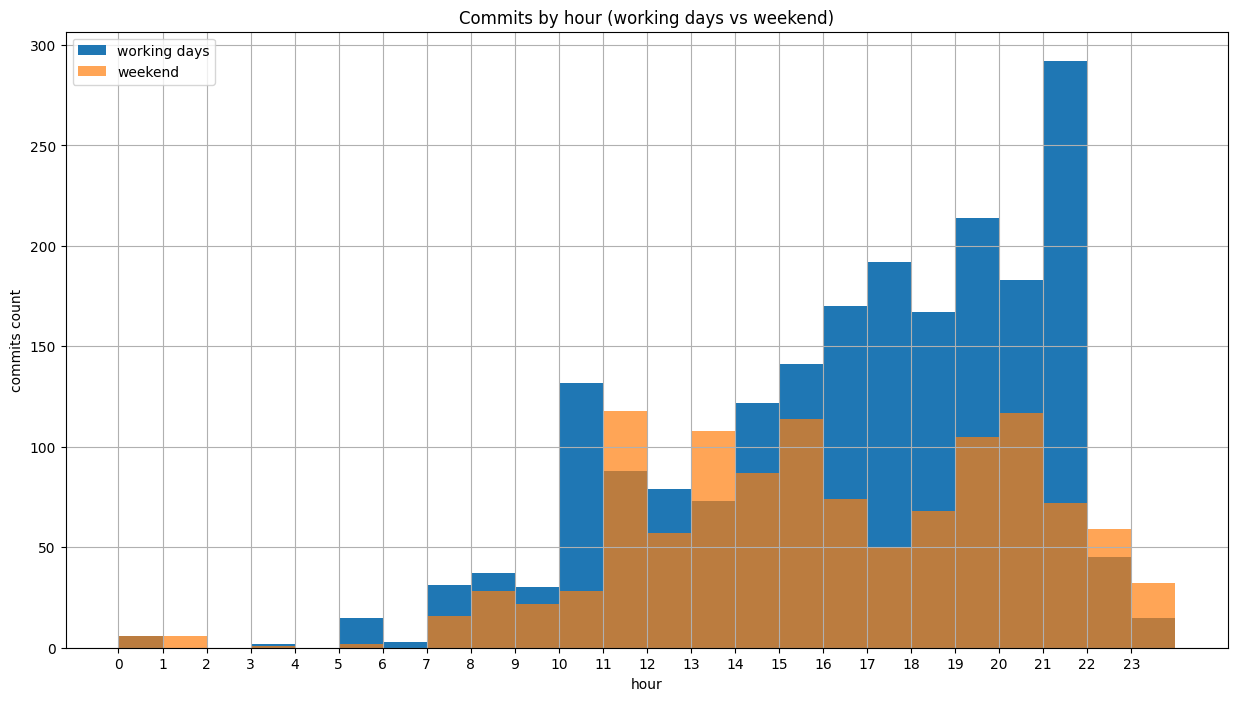

In [10]:
plt.figure(figsize=(15, 8))

# bins من 0 ل 24 عشان كل ساعة تبقى عمود واضح
bins = list(range(0, 25))

plt.hist(hours_working, bins=bins, label="working days")
plt.hist(hours_weekend, bins=bins, alpha=0.7, label="weekend")  # front transparency = 0.7

plt.xticks(range(0, 24))
plt.legend()
plt.title("Commits by hour (working days vs weekend)")
plt.xlabel("hour")
plt.ylabel("commits count")
plt.grid(True)
plt.show()

In [11]:
work_counts = pd.Series(hours_working).value_counts().sort_index()
week_counts = pd.Series(hours_weekend).value_counts().sort_index()

diff = (week_counts - work_counts).dropna()
top4 = diff[diff > 0].sort_values(ascending=False).head(4)
top4

13    35.0
11    30.0
23    17.0
22    14.0
Name: count, dtype: float64

## Answer

Are there hours when the total number of commits was higher on weekends than on working days?

Top 4 examples (hour -> weekend minus working days):
- **H1** -> **D1**
- **H2** -> **D2**
- **H3** -> **D3**
- **H4** -> **D4**